In [123]:
from __future__ import annotations

import contextlib
import ctypes
import gc
import hashlib
import itertools
import json
import logging
import os

from collections.abc import Iterable
from dataclasses import dataclass, replace
from pathlib import Path
from typing import TYPE_CHECKING, Any, cast

import numpy as np
import torch
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from tqdm import tqdm

from qqe.backend import PennylaneBackend, QuimbBackend
from qqe.circuit.families import (
    CliffordBrickwork,
)

# Keep this import path only if it is the correct one in your project.
# If your real function lives in qqe.circuit.matrix_factory, switch it there.
from qqe.circuit.gates import clifford_recipe_unitary, gate_unitary
from qqe.circuit.patterns import TdopingRules, brickwork_pattern, to_qasm
from qqe.circuit.spec import CircuitSpec, GateSpec
from qqe.experiments.core import ExperimentConfig, run_experiment
from qqe.GNN.encoder import eigenvalue_phase_histogram_features, qasm_to_pyg_graph
from qqe.properties.compute import PropertyRequest
from qqe.rng.seeds import gate_seed
from qqe.states.types import BackendConfig
from qqe.utils import FileCache

if TYPE_CHECKING:
    from collections.abc import Generator

    from qqe.circuit.spec import GateSpec


### Haar

In [124]:
@dataclass(frozen=True)
class HaarBrickwork:
    """Haar random circuit family with brickwork pattern.

    Attributes:
        name: The name of the circuit family.
    """

    name: str = "haar"

    def make_spec(
        self,
        n_qubits: int,
        n_layers: int,
        d: int,
        seed: int,
        *,
        connectivity: str = "line",
        pattern: str = "brickwork",
        **kwargs: Any,
    ) -> CircuitSpec:
        params = dict(kwargs)

        spec = CircuitSpec(
            n_qubits=int(n_qubits),
            n_layers=int(n_layers),
            d=int(d),
            global_seed=int(seed),
            family=self.name,
            connectivity=connectivity,
            pattern=pattern,
            params=params,
        )
        return replace(spec, gates=tuple(self.gates(spec)))

    def gates(self, spec: CircuitSpec) -> Generator[GateSpec]:
        gate_probability = float(spec.params.get("gate_probability", 1.0))

        for layer in range(spec.n_layers):
            pairs = brickwork_pattern(spec.n_qubits, layer, connectivity=spec.connectivity)

            for slot, (a, b) in enumerate(pairs):
                s = gate_seed(
                    spec.global_seed,
                    layer=layer,
                    slot=slot,
                    wires=(a, b),
                    kind="haar",
                )
                rng = np.random.default_rng(s)
                if rng.random() > gate_probability:
                    yield GateSpec(
                        kind="I",
                        wires=(int(a),),
                        d=spec.d,
                        seed=s,
                        tags=("layer", f"L{layer}", "haar_skipped_identity", f"wire_{a}"),
                        params=(),
                    )
                    yield GateSpec(
                        kind="I",
                        wires=(int(b),),
                        d=spec.d,
                        seed=s,
                        tags=("layer", f"L{layer}", "haar_skipped_identity", f"wire_{b}"),
                        params=(),
                    )
                    continue

                yield GateSpec(
                    kind="haar",
                    wires=(a, b),
                    d=spec.d,
                    seed=s,
                    tags=("layer", f"L{layer}", "haar"),
                    params=(s,),
                )


### Quansistor

In [125]:
def quansistor_blocks(n_qubits: int, n_layer: int) -> list[tuple[int, int, int, int]]:
    start = (n_layer % 2) * 2  # shift by 2 wires each odd layer
    blocks: list[tuple[int, int, int, int]] = []
    for i in range(start, n_qubits - 3, 4):
        blocks.append((i, i + 1, i + 2, i + 3))
    return blocks

def sample_quansistor_params(
    rng: np.random.Generator,
    param_regime: str,
    param_scale: float | None = None,
) -> tuple[float, float, float]:
    if param_regime == "identity_like":
        sigma = 0.02 if param_scale is None else float(param_scale)
        a, b, g = rng.normal(0.0, sigma, 3)

    elif param_regime == "weak":
        sigma = 0.20 if param_scale is None else float(param_scale)
        a, b, g = rng.normal(0.0, sigma, 3)

    elif param_regime == "moderate":
        sigma = 0.75 if param_scale is None else float(param_scale)
        a, b, g = rng.normal(0.0, sigma, 3)

    elif param_regime == "structured_equal_ab":
        scale = np.pi if param_scale is None else float(param_scale) * np.pi
        base = rng.uniform(-scale, scale)
        g = rng.uniform(-0.25, 0.25)
        a, b = base, base

    elif param_regime == "structured_opposite_ab":
        scale = np.pi if param_scale is None else float(param_scale) * np.pi
        base = rng.uniform(-scale, scale)
        g = rng.uniform(-0.25, 0.25)
        a, b = base, -base

    elif param_regime == "generic_uniform":
        a, b, g = rng.uniform(-np.pi, np.pi, 3)

    else:
        raise ValueError(f"Unknown param_regime={param_regime}")

    return float(a), float(b), float(g)


def leftover_pairs(n_qubits: int, used: set[int], connectivity: str) -> list[tuple[int, int]]:
    left = [i for i in range(n_qubits) if i not in used]
    leftover = set(left)

    pairs: list[tuple[int, int]] = []
    used = set()

    for i in range(n_qubits - 1):
        a, b = i, i + 1
        if a in leftover and b in leftover and a not in used and b not in used:
            pairs.append((a, b))
            used.update((a, b))
    if connectivity in ("loop", "ring"):
        a, b = n_qubits - 1, 0
        if a in leftover and b in leftover and a not in used and b not in used:
            pairs.append((a, b))
            used.update((a, b))
    return pairs

def kv(**kwargs) -> tuple[str, ...]:
    # deterministic ordering
    return tuple(f"{k}={v}" for k, v in sorted(kwargs.items()))

def _axis_from_seed(seed: int) -> str:
    # deterministic, reproducible across runs
    rng = np.random.default_rng(seed)
    return "X" if rng.integers(0, 2) == 0 else "Y"

_BLOCK_STEPS = (
    (0, 1),  # q0 q1
    (2, 3),  # q2 q3
    (1, 2),  # q1 q2
    (0, 1),  # q0 q1
    (2, 3),  # q2 q3
)

@dataclass(frozen=True)
class QuansistorBrickwork:
    name: str = "quansistor"

    def make_spec(
        self,
        n_qubits: int,
        n_layers: int,
        d: int,
        seed: int,
        *,
        connectivity: str = "line",
        pattern: str = "brickwork",
        **kwargs: Any,
    ) -> CircuitSpec:
        params = dict(kwargs)
        spec = CircuitSpec(
            n_qubits=n_qubits,
            n_layers=n_layers,
            d=d,
            global_seed=seed,
            family=self.name,
            connectivity=connectivity,
            pattern=pattern,
            params=params,
        )
        return replace(spec, gates=tuple(self.gates(spec)))

    def gates(self, spec: CircuitSpec) -> Iterable[GateSpec]:
        if spec.pattern == "custom":
            for layer in range(spec.n_layers):
                blocks = quansistor_blocks(spec.n_qubits, layer)
                used: set[int] = set()

                # ---- 4-qubit blocks -> 5 two-qubit gates each
                for block_idx, (q0, q1, q2, q3) in enumerate(blocks):
                    used.update((q0, q1, q2, q3))

                    # One seed namespace per block (so 5 gates share a single RNG stream conceptually)
                    # We derive per-step seeds deterministically from that block identity.
                    block_seed = gate_seed(
                        spec.global_seed,
                        kind="quansistor_block",
                        layer=layer,
                        slot=block_idx,
                        wires=(q0, q1, q2, q3),
                        ordered_wires=True,
                    )

                    # Emit the 5 sequential 2-qubit quansistor gates
                    wires4 = (q0, q1, q2, q3)
                    for step_idx, (i, j) in enumerate(_BLOCK_STEPS):
                        a, b = wires4[i], wires4[j]

                        # step seed derived from block_seed (NOT spec.global_seed directly)
                        s = gate_seed(
                            block_seed,
                            kind="quansistor",
                            layer=step_idx,  # local to block
                            slot=0,
                            wires=(a, b),
                            ordered_wires=True,
                            extra=f"L{layer}_B{block_idx}_S{step_idx}",
                        )

                        yield GateSpec(
                            kind="quansistor",
                            wires=(a, b),
                            d=spec.d,
                            seed=s,
                            tags=(
                                "layer",
                                f"L{layer}",
                                "block",
                                f"B{block_idx}",
                                "step",
                                f"S{step_idx}",
                            ),
                            params=(("block", (q0, q1, q2, q3)), ("step", step_idx)),
                        )
        elif spec.pattern == "brickwork":
            for layer in range(spec.n_layers):
                pairs = brickwork_pattern(spec.n_qubits, layer, connectivity=spec.connectivity)

                for slot, (a, b) in enumerate(pairs):
                    s = gate_seed(
                        spec.global_seed,
                        layer=layer,
                        slot=slot,
                        wires=(a, b),
                        kind="quansistor",
                    )
                    rng = np.random.default_rng(s)

                    gate_probability = float(spec.params.get("gate_probability", 1.0))
                    param_regime = str(spec.params.get("param_regime", "generic_uniform"))
                    param_scale = spec.params.get("param_scale", None)

                    a_, b_, g_ = sample_quansistor_params(
                        rng=rng,
                        param_regime=param_regime,
                        param_scale=param_scale,
                    )

                    if rng.random() > gate_probability:
                        yield GateSpec(
                            kind="I",
                            wires=(int(a),),
                            d=spec.d,
                            seed=s,
                            tags=("layer", f"L{layer}", "quansistor_skipped_identity", f"wire_{a}"),
                            params=(),
                        )
                        yield GateSpec(
                            kind="I",
                            wires=(int(b),),
                            d=spec.d,
                            seed=s,
                            tags=("layer", f"L{layer}", "quansistor_skipped_identity", f"wire_{b}"),
                            params=(),
                        )
                        continue


                    axis = str(rng.choice(["X", "Y"]))
                    params = (float(a_), float(b_), float(g_), axis)

                    yield GateSpec(
                        kind="quansistor",
                        wires=(int(a), int(b)),
                        d=spec.d,
                        seed=s,
                        tags=(
                            "layer",
                            f"L{layer}",
                            "quansistor",
                            f"axis_{axis}",
                            f"wire_{a}_{b}",
                            f"regime_{param_regime}",
                        ),
                        params=params,
                    )

### Rotation

In [126]:
@dataclass(frozen=True)
class RandomCircuit:
    name: str = "random"
    p_cnot: float = 0.8
    rot_set: tuple[str, ...] = ("RX", "RY", "RZ")

    def make_spec(
        self,
        n_qubits: int,
        n_layers: int,
        d: int,
        seed: int,
        *,
        connectivity: str = "line",
        pattern: str = "random",
        **kwargs: Any,
    ) -> CircuitSpec:
        params = dict(kwargs)

        spec = CircuitSpec(
            n_qubits=n_qubits,
            n_layers=n_layers,
            d=d,
            global_seed=seed,
            family=self.name,
            connectivity=connectivity,
            pattern=pattern,
            params=params,
        )
        return replace(spec, gates=tuple(self.gates(spec)))

    def _allowed_edges(self, n: int, connectivity: str) -> list[tuple[int, int]]:
        if connectivity == "line":
            return [(i, i + 1) for i in range(n - 1)]
        if connectivity == "ring":
            return [(i, (i + 1) % n) for i in range(n)]
        if connectivity == "all":
            return [(i, j) for i in range(n) for j in range(i + 1, n)]
        raise ValueError(f"Unknown connectivity={connectivity}")

    def _random_disjoint_pairs(
        self, n: int, rng: np.random.Generator,
    ) -> list[tuple[int, int]]:
        """Random perfect-ish matching on vertices (ignores hardware edges)."""
        perm = rng.permutation(n).tolist()
        return [(perm[i], perm[i + 1]) for i in range(0, n - 1, 2)]

    def _random_disjoint_pairs_on_edges(
        self, n: int, edges: list[tuple[int, int]], rng: np.random.Generator,
    ) -> list[tuple[int, int]]:
        """Random maximal matching restricted to a given edge set.
        Greedy: shuffle edges, take if both endpoints unused.
        """
        edges_shuffled = edges.copy()
        rng.shuffle(edges_shuffled)

        used = set()
        pairs: list[tuple[int, int]] = []
        for a, b in edges_shuffled:
            if a in used or b in used:
                continue
            used.add(a); used.add(b)
            pairs.append((a, b))
        return pairs

    def _sample_rotation_angle(
        self,
        rng: np.random.Generator,
        angle_regime: str,
        angle_scale: float | None,
    ) -> float:
        if angle_regime == "identity_like":
            scale = 0.02 if angle_scale is None else float(angle_scale)
            return float(rng.normal(0.0, scale))

        if angle_regime == "clifford_like":
            scale = 0.02 if angle_scale is None else float(angle_scale)
            base = float(rng.choice([0.0, np.pi / 2, np.pi, 3 * np.pi / 2]))
            return float(base + rng.normal(0.0, scale))

        if angle_regime == "small_angles":
            scale = 0.25 if angle_scale is None else float(angle_scale)
            return float(rng.normal(0.0, scale))

        if angle_regime == "generic":
            return float(rng.uniform(0.0, 2 * np.pi))

        raise ValueError(f"Unknown angle_regime={angle_regime}")

    def gates(self, spec: CircuitSpec) -> Iterable[GateSpec]:
        p_cnot = float(spec.params.get("p_cnot", self.p_cnot))
        rot_set = tuple(spec.params.get("rot_set", self.rot_set))
        n = spec.n_qubits
        gate_probability = float(spec.params.get("gate_probability", 1.0))
        angle_regime = str(spec.params.get("angle_regime", "generic"))
        angle_scale = spec.params.get("angle_scale", None)

        allowed_edges = self._allowed_edges(n, spec.connectivity)


        for step in range(spec.n_layers):
            # one seed per "step" so the sampling matches "one random gate per step"
            for wire in range(n):
                s1 = gate_seed(
                    spec.global_seed,
                    layer=step,
                    slot=wire,
                    wires=(wire,),
                    kind="random",
                )
                rng1 = np.random.default_rng(s1)
                kind = str(rng1.choice(rot_set))
                theta = rng1.uniform(0, 2 * np.pi)
                yield GateSpec(
                    kind=kind,
                    wires=(wire,),
                    d=spec.d,
                    seed=s1,
                    params=(theta,),
                    tags=(
                        "layer",
                        f"L{step}",
                        "1q",
                        kind,
                    ),
                )
            s2 = gate_seed(
                spec.global_seed,
                layer=step,
                slot=0,
                wires=(),
                kind="pairing",
                ordered_wires=True,
            )
            rng2 = np.random.default_rng(s2)
            pairs = self._random_disjoint_pairs_on_edges(n, allowed_edges, rng2)
            for slot, (a, b) in enumerate(pairs):
                s3 = gate_seed(
                    spec.global_seed,
                    layer=step,
                    slot=slot,
                    wires=(a, b),
                    kind="cnot",
                    ordered_wires=True,
                )
                rng3 = np.random.default_rng(s3)

                if rng3.random() < p_cnot * gate_probability:
                    ctrl, tgt = (a, b) if rng3.random() < 0.5 else (b, a)
                    yield GateSpec(
                        kind="CNOT",
                        wires=(ctrl, tgt),
                        d=spec.d,
                        seed=s3,
                        params=(),
                        tags=("layer", f"L{step}", "2q", "CNOT"),
                    )

## Circuit sampling

In [127]:
BACKEND_REGISTRY = {
    "pennylane": PennylaneBackend,
    "quimb": QuimbBackend,
}

FAMILY_REGISTRY = {
    "haar": HaarBrickwork,
    "clifford": CliffordBrickwork,
    "quansistor": QuansistorBrickwork,
    "random": RandomCircuit,
}

In [128]:
def sample_gate_probability(rng: np.random.Generator) -> float:
    regime = rng.choice(
        ["very_sparse", "sparse", "medium", "dense"],
        p=[0.15, 0.25, 0.35, 0.25],
    )

    if regime == "very_sparse":
        return rng.uniform(0.05, 0.15)

    if regime == "sparse":
        return rng.uniform(0.15, 0.35)

    if regime == "medium":
        return rng.uniform(0.35, 0.65)

    if regime == "dense":
        return rng.uniform(0.65, 1.0)

    raise ValueError(regime)

In [129]:
def build_op_descriptors_from_spec(
    gates: tuple[GateSpec, ...] | None,
    family: str,
) -> list[dict[str, Any]] | None:
    """Build per-gate descriptor metadata aligned with the parsed QASM op order.

    Only Haar gates need a nonzero fixed-size node descriptor block.
    All other gates may still keep metadata, but should not carry a Haar descriptor.
    """
    if gates is None:
        return None

    op_descriptors: list[dict[str, Any]] = []

    for gate in gates:
        kind = str(gate.kind).lower()
        kind_norm = "haar" if kind == "haar2" else kind

        descriptor: dict[str, Any] = {
            "kind": kind_norm,
            "wires": tuple(gate.wires),
            "params": gate.params,
            "seed": gate.seed,
            "d": gate.d,
        }

        if family == "haar" and kind_norm == "haar":
            U = gate_unitary(gate)
            descriptor["haar_descriptor"] = eigenvalue_phase_histogram_features(U)

        op_descriptors.append(descriptor)

    return op_descriptors

In [130]:
def sample_t_count(n_layers: int, rng: np.random.Generator) -> tuple[str, int]:
    max_t = 2 * n_layers

    regime: str = rng.choice(
        ["zero", "low", "medium", "high"],
        p=[0.15, 0.35, 0.30, 0.20],
    )
    # print(f"Sampling t count with regime: {regime}")

    if regime == "zero":
        N_T: int = 0

    if regime == "low":
        N_T = rng.integers(1, max(2, max_t // 4 + 1))

    if regime == "medium":
        N_T = rng.integers(max(1, max_t // 4), max(2, max_t // 2 + 1))

    if regime == "high":
        N_T = rng.integers(max(1, max_t // 2), max_t + 1)

    return (regime, int(N_T))

In [131]:
def sample_haar_probability(rng: np.random.Generator) -> tuple[str, float]:
    regime = rng.choice(
        ["none", "low", "medium", "high"],
        p=[0.10, 0.30, 0.35, 0.25],
    )

    if regime == "none":
        p_haar = 0.0

    if regime == "low":
        p_haar = rng.uniform(0.05, 0.25)

    if regime == "medium":
        p_haar = rng.uniform(0.25, 0.60)

    if regime == "high":
        p_haar = rng.uniform(0.60, 1.0)

    return regime, p_haar

In [132]:
def sample_rot_angles(rng: np.random.Generator) -> tuple[str, float]:
    regime = rng.choice(
        ["zero_like", "clifford_like", "small", "generic"],
        p=[0.15, 0.20, 0.30, 0.35],
    )

    if regime == "zero_like":
        angle = rng.normal(loc=0.0, scale=0.02)

    if regime == "clifford_like":
        base = rng.choice([0, np.pi / 2, np.pi, 3 * np.pi / 2])
        angle = base + rng.normal(loc=0.0, scale=0.02)

    if regime == "small":
        angle = rng.normal(loc=0.0, scale=0.25)

    if regime == "generic":
        angle = rng.uniform(0.0, 2 * np.pi)

    return regime, angle

In [133]:
def sample_quansistor_params(rng: np.random.Generator):
    regime = rng.choice(
        ["identity_like", "weak", "structured", "generic"],
        p=[0.15, 0.25, 0.25, 0.35],
    )

    if regime == "identity_like":
        a = rng.normal(0.0, 0.02)
        b = rng.normal(0.0, 0.02)
        g = rng.normal(0.0, 0.02)

    elif regime == "weak":
        a = rng.normal(0.0, 0.20)
        b = rng.normal(0.0, 0.20)
        g = rng.normal(0.0, 0.20)

    elif regime == "structured":
        base = rng.normal(0.0, 0.5)
        a = base
        b = base
        g = rng.normal(0.0, 0.1)

    elif regime == "generic":
        a = rng.normal(0.0, 1.0)
        b = rng.normal(0.0, 1.0)
        g = rng.normal(0.0, 1.0)

    else:
        raise ValueError(regime)

    return regime, a, b, g

In [134]:
def sample_generation_controls(
    family: str,
    n_layers: int,
    seed: int,
) -> dict[str, Any]:
    rng = np.random.default_rng(int(seed))

    controls: dict[str, Any] = {
        "sampling_regime": "default",
        "tdoping": None,
        "t_count": None,
        "gate_probability": None,
        "angle_regime": None,
        "angle_scale": None,
        "haar_probability": None,
        "param_regime": None,
        "param_scale": None,
    }

    if family == "clifford":
        regime, t_count = sample_t_count(int(n_layers), rng)

        controls["sampling_regime"] = str(regime)
        controls["t_count"] = int(t_count)
        controls["tdoping"] = TdopingRules(count=int(t_count), per_layer=2)

    elif family == "haar":
        regime, p_haar = sample_haar_probability(rng)

        controls["sampling_regime"] = str(regime)
        controls["haar_probability"] = float(p_haar)
        controls["gate_probability"] = float(p_haar)

    elif family == "random":
        regime = str(
            rng.choice(
                ["identity_like", "clifford_like", "small_angles", "generic"],
                p=[0.15, 0.20, 0.30, 0.35],
            )
        )

        controls["sampling_regime"] = regime
        controls["angle_regime"] = regime

        if regime == "identity_like":
            controls["gate_probability"] = float(rng.uniform(0.05, 0.20))
            controls["angle_scale"] = 0.02

        elif regime == "clifford_like":
            controls["gate_probability"] = float(rng.uniform(0.20, 0.60))
            controls["angle_scale"] = 0.02

        elif regime == "small_angles":
            controls["gate_probability"] = float(rng.uniform(0.30, 0.80))
            controls["angle_scale"] = 0.25

        elif regime == "generic":
            controls["gate_probability"] = float(rng.uniform(0.60, 1.00))
            controls["angle_scale"] = None

        else:
            raise ValueError(f"Unknown random regime={regime}")

    elif family == "quansistor":
        regime = str(
            rng.choice(
                [
                    "identity_like",
                    "weak",
                    "moderate",
                    "structured_equal_ab",
                    "structured_opposite_ab",
                    "generic_uniform",
                ],
                p=[0.10, 0.20, 0.25, 0.15, 0.15, 0.15],
            ),
        )

        controls["sampling_regime"] = regime
        controls["param_regime"] = regime

        if regime == "identity_like":
            controls["gate_probability"] = float(rng.uniform(0.05, 0.30))
            controls["param_scale"] = 0.02

        elif regime == "weak":
            controls["gate_probability"] = float(rng.uniform(0.20, 0.60))
            controls["param_scale"] = 0.20

        elif regime == "moderate":
            controls["gate_probability"] = float(rng.uniform(0.40, 0.85))
            controls["param_scale"] = 0.75

        elif regime == "structured_equal_ab" or regime == "structured_opposite_ab":
            controls["gate_probability"] = float(rng.uniform(0.30, 0.80))
            controls["param_scale"] = 1.00

        elif regime == "generic_uniform":
            controls["gate_probability"] = float(rng.uniform(0.50, 1.00))
            controls["param_scale"] = None

        else:
            msg = f"Unknown quansistor regime={regime}"
            raise ValueError(msg)

    return controls

# Dataset creation

In [135]:
def generate_circuit(
    n_qubits: int,
    n_layers: int,
    family: str = "haar",
    backend: str = "pennylane",
    seed: int = 42,
) -> tuple[Data, dict[str, int], dict[str, Any], float | None]:
    controls = sample_generation_controls(
        family=family,
        n_layers=int(n_layers),
        seed=int(seed),
    )

    make_spec_kwargs = {
        "d": 2,
        "seed": int(seed),
    }

    if family == "clifford":
        make_spec_kwargs["tdoping"] = controls["tdoping"]

    elif family == "random":
        make_spec_kwargs["angle_regime"] = controls["angle_regime"]
        make_spec_kwargs["angle_scale"] = controls.get("angle_scale")
        make_spec_kwargs["gate_probability"] = controls["gate_probability"]

    elif family == "haar":
        make_spec_kwargs["gate_probability"] = controls["gate_probability"]

    elif family == "quansistor":
        make_spec_kwargs["param_regime"] = controls["param_regime"]
        make_spec_kwargs["param_scale"] = controls.get("param_scale")
        make_spec_kwargs["gate_probability"] = controls["gate_probability"]

    spec = family_obj.make_spec(
        int(n_qubits),
        int(n_layers),
        **make_spec_kwargs,
    )

    gates = cast("tuple[GateSpec, ...] | None", spec.gates)
    qasm = to_qasm(spec, gates)
    op_descriptors = build_op_descriptors_from_spec(gates, family)

    graph_data, gate_counts = qasm_to_pyg_graph(
        qasm_str=qasm,
        n_bins=50,
        family=family,
        global_feature_variant="binned",
        op_descriptors=op_descriptors,
    )

    cache = None
    backend_config = BackendConfig(
        name=backend,
        representation="dense",
        params={},
    )

    property_request = PropertyRequest(
        name="SRE",
        method="fwht",
        params={},
    )

    exp_config = ExperimentConfig(
        spec=spec,
        backend=backend_config,
        properties=[property_request],
    )

    backend_factory = BACKEND_REGISTRY["pennylane"]
    backend_instance = (
        backend_factory() if callable(backend_factory) else backend_factory
    )

    state = backend_instance.simulate(
        spec,
        representation="dense",
    )

    result = run_experiment(
        exp_config,
        backend_registry=BACKEND_REGISTRY,
        state=state,
        cache=cache,
    )

    sre_result = result.results.get("SRE")
    sre_value = float(sre_result.value) if sre_result else None

    return (
        graph_data,
        gate_counts,
        controls,
        sre_value,
    )

### Clifford

In [136]:
n_qubits = 8
n_layers = 100
family = "clifford"
backend = "pennylane"
seed = 10

rng = np.random.default_rng(seed)

In [137]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [138]:
sre_values_cliff = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    sre_values_cliff.append(sre_value)

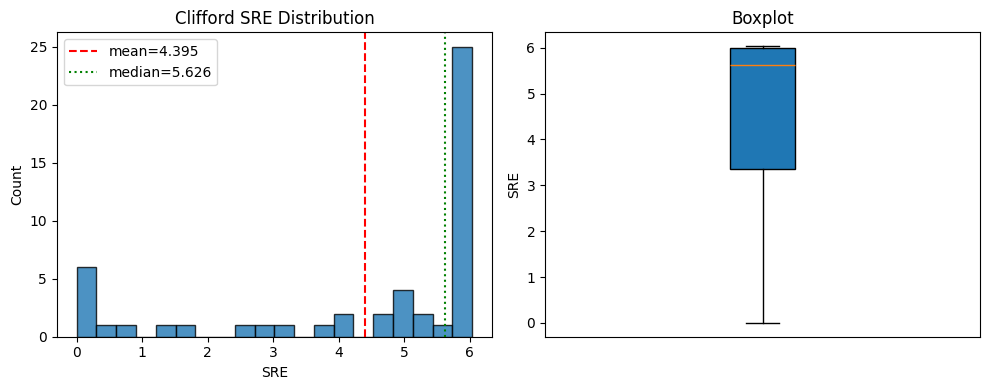

In [139]:
def plot_sre_distribution(
    sre_values,
    bins: int = 20,
    title: str = "SRE Distribution",
    figsize: tuple[int, int] = (10, 4),
):
    vals = np.asarray(sre_values, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        print("No valid SRE values to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histogram
    axes[0].hist(vals, bins=bins, edgecolor="black", alpha=0.8)
    axes[0].axvline(vals.mean(), color="red", linestyle="--", label=f"mean={vals.mean():.3f}")
    axes[0].axvline(np.median(vals), color="green", linestyle=":", label=f"median={np.median(vals):.3f}")
    axes[0].set_title(title)
    axes[0].set_xlabel("SRE")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    # Boxplot
    axes[1].boxplot(vals, vert=True, patch_artist=True)
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("SRE")
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()


# Example: use already computed values
plot_sre_distribution(sre_values_cliff, bins=20, title="Clifford SRE Distribution")

### Haar-like

In [140]:
n_qubits = 8
n_layers = 100
family = "haar"
backend = "pennylane"
seed = 10

In [141]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [142]:
sre_values_haar = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    sre_values_haar.append(sre_value)

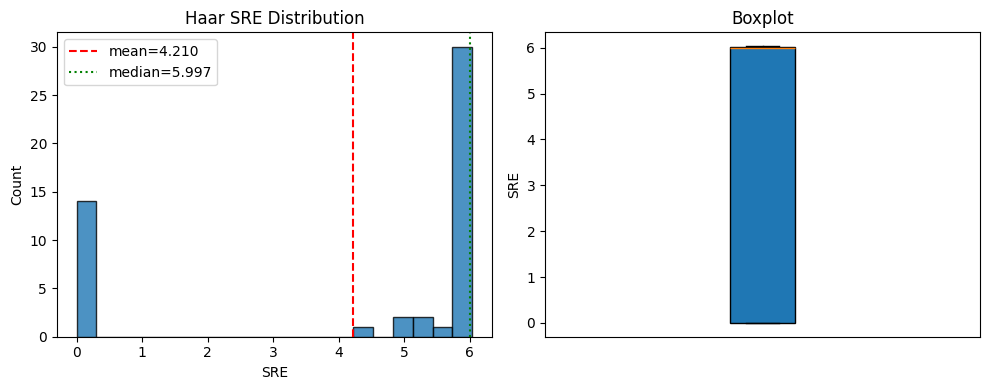

In [143]:
plot_sre_distribution(sre_values_haar, bins=20, title="Haar SRE Distribution")

### Random rotations

In [144]:
n_qubits = 8
n_layers = 100
family = "random"
backend = "pennylane"
seed = 10

In [145]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [146]:
sre_values_random = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    sre_values_random.append(sre_value)

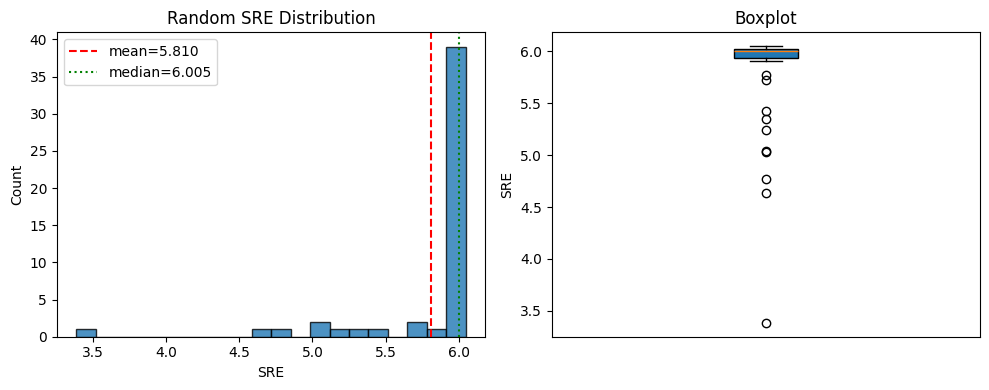

In [147]:
plot_sre_distribution(sre_values_random, bins=20, title="Random SRE Distribution")

### Quansistor

In [148]:
n_qubits = 8
n_layers = 100
family = "quansistor"
backend = "pennylane"
seed = 10

In [149]:
family_cls = FAMILY_REGISTRY[family]
family_obj = family_cls()

In [150]:
sre_values_quansistor = []

for s in range(50):
    graph_data, gate_counts, controls, sre_value = generate_circuit(
        n_qubits=n_qubits,
        n_layers=n_layers,
        family=family,
        backend=backend,
        seed=int(s + rng.integers(0, 1_000_000)),
    )
    sre_values_quansistor.append(sre_value)

TypeError: sample_quansistor_params() got an unexpected keyword argument 'param_regime'

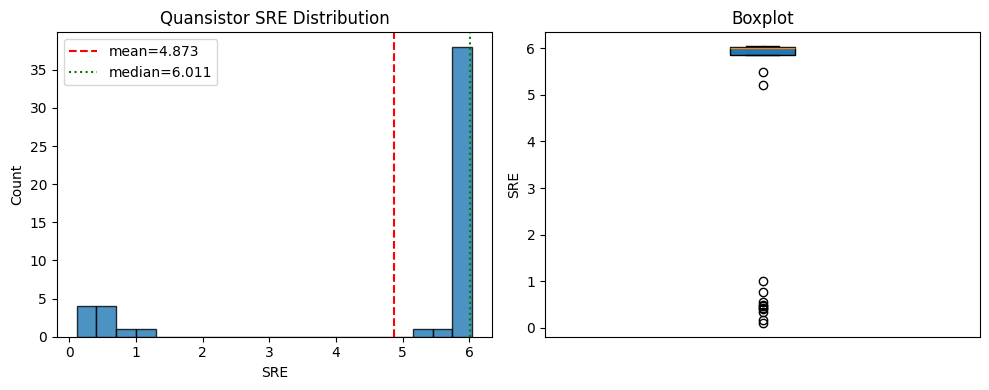

In [ ]:
plot_sre_distribution(sre_values_quansistor, bins=20, title="Quansistor SRE Distribution")

## Quansistor parameters

In [ ]:
def circ_X(a, b, g):
    """Creates a matrix of symmetry class X defined in section A of
    https://doi.org/10.1103/PhysRevA.106.062610.
    
    @param a: Parameter alpha defined in equation 18 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param b: Parameter beta defined in equation 18 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param g: Parameter gamma defined in equation 18 of
    https://doi.org/10.1103/PhysRevA.106.062610.

    @return: Matrix of symmetry class X.
    """
    # Matrix implementation in logical basis.
    # Obtained from Eqn.33 of paper.

    # Eigenvalues lambda_0,...,lambda_3. Note lambda_0=lambda_4 from paper.
    l0 = 2 * a + g
    l1 = -2 * b - g
    l2 = -2 * a + g
    l3 = 2 * b - g

    e0 = 0.25 * np.exp(-1.0j * l0)
    e1 = 0.25 * np.exp(-1.0j * l1)
    e2 = 0.25 * np.exp(-1.0j * l2)
    e3 = 0.25 * np.exp(-1.0j * l3)

    e11 = e0 + e1 + e2 + e3
    e12 = e0 - 1.0j * e1 - e2 + 1.0j * e3
    e13 = e0 - e1 + e2 - e3
    e14 = e0 + 1.0j * e1 - e2 - 1.0j * e3

    return np.array(
        [
            [e11, e12, e13, e14],
            [e14, e11, e12, e13],
            [e13, e14, e11, e12],
            [e12, e13, e14, e11],
        ],
    )


def circ_Y(a, b, g):
    """Creates a matrix of symmetry class Y defined in section B of
    https://doi.org/10.1103/PhysRevA.106.062610.
    
    @param a: Parameter alpha defined in equation 23 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param b: Parameter beta defined in equation 23 of
    https://doi.org/10.1103/PhysRevA.106.062610.
    @param g: Parameter gamma defined in equation 23 of
    https://doi.org/10.1103/PhysRevA.106.062610.

    @return: Matrix of symmetry class Y.
    """
    # Matrix implementation in logical basis.
    # Obtained from Eqn.33 of paper.

    # Constants
    SQRT2 = np.sqrt(2)
    E_I_PI_OVER_4 = (1 + 1.0j) / SQRT2
    E_I_3_PI_OVER_4 = (-1 + 1.0j) / SQRT2

    # Eigenvalues lambda_0,...,lambda_3. Note lambda_0 = lambda_4 from paper.
    l0 = SQRT2 * a + SQRT2 * b + g
    l1 = SQRT2 * a - SQRT2 * b - g
    l2 = -SQRT2 * a - SQRT2 * b + g
    l3 = -SQRT2 * a + SQRT2 * b - g

    e0 = 0.25 * np.exp(-1.0j * l0)
    e1 = 0.25 * np.exp(-1.0j * l1)
    e2 = 0.25 * np.exp(-1.0j * l2)
    e3 = 0.25 * np.exp(-1.0j * l3)

    e11 = e0 + e1 + e2 + e3
    e12 = e0 - 1.0j * e1 - e2 + 1.0j * e3
    e13 = -e0 + e1 - e2 + e3
    e14 = e0 + 1.0j * e1 - e2 - 1.0j * e3
    e23a = (e0 - e2) * E_I_3_PI_OVER_4
    e23b = (e1 - e3) * E_I_PI_OVER_4
    e24 = e0 - e1 + e2 - e3
    e34a = -(e0 - e2) * E_I_PI_OVER_4
    e34b = -(e1 - e3) * E_I_3_PI_OVER_4

    return np.array(
        [
            [e11, E_I_PI_OVER_4 * e12, e13, E_I_PI_OVER_4 * e14],
            [-E_I_3_PI_OVER_4 * e14, e11, e23a + e23b, e24],
            [e13, e34a + e34b, e11, e34a - e34b],
            [-E_I_3_PI_OVER_4 * e12, e24, e23a - e23b, e11],
        ],
    )

In [ ]:
a, b, g = 0.5, 1.0, 0.0
U_X = circ_X(a, b, g)
U_Y = circ_Y(a, b, g)

In [ ]:
print("Unitary of symmetry class X:")
print(U_X)
print("Unitary of symmetry class Y:")
print(U_Y)

Unitary of symmetry class X:
[[ 0.06207773+0.j          0.45464871-0.42073549j  0.47822457+0.j
  -0.45464871-0.42073549j]
 [-0.45464871-0.42073549j  0.06207773+0.j          0.45464871-0.42073549j
   0.47822457+0.j        ]
 [ 0.47822457+0.j         -0.45464871-0.42073549j  0.06207773+0.j
   0.45464871-0.42073549j]
 [ 0.45464871-0.42073549j  0.47822457+0.j         -0.45464871-0.42073549j
   0.06207773+0.j        ]]
Unitary of symmetry class Y:
[[ 0.11855535+0.j          0.5309974 -0.07163471j  0.64168925+0.j
   0.07163471-0.5309974j ]
 [-0.5309974 -0.07163471j  0.11855535+0.j          0.07163471+0.5309974j
  -0.64168925+0.j        ]
 [ 0.64168925+0.j         -0.07163471+0.5309974j   0.11855535+0.j
  -0.5309974 +0.07163471j]
 [-0.07163471-0.5309974j  -0.64168925+0.j          0.5309974 +0.07163471j
   0.11855535+0.j        ]]
